> 本案例在 `ClusterSpace(..., asr=True)` 初始化时构造声学零空间，并在该子空间内拟合。
> 下方完整执行输出对应这一 ASR 路线。

# K4As4Pt2：FC2–FC4 拟合、热导率与 SCPH

本教程把 mlfcs 的三大阶段串成一条完整流水线：

1. **拟合**：`FitSystem` 在初始化 ASR 零空间内联合拟合 FC2–FC4（10 原子原胞、$2\times2\times3$
   120 原子参考超胞；截断 FC2 6.5 Å、FC3 $12a_0$、FC4 $8a_0$，最大体序 2/3/3）；
2. **输运**：导出稠密 FC2/FC3 HDF5，phono3py RTA 计算
   $10\times10\times10$ 网格、300–900 K 的晶格热导率；
3. **SCPH**：以拟合力常数为起点，跑四阶环近似的自洽声子（SCPH）温度序列，
   画温度相关的声子谱。

训练数据 `train.extxyz` 由本案例的原胞、超胞与 ALAMODE 随机位移数据转换而
来，力已存储在帧内，因此拟合不需要外部计算器。这是教程中最长的 notebook；
各阶段共用同一个内存模型，按顺序执行即可。

In [1]:
from pathlib import Path
import tempfile
import warnings

import matplotlib.pyplot as plt
import numpy as np
from ase.io import iread, read
from ase.units import Bohr
from phonopy.structure.cells import PrimitiveMatrixAutoDefaultWarning

import mlfcs
from mlfcs import ClusterMap, ClusterSpace, FitSystem
from mlfcs.phonon import Harmonic, SCPH

# phonopy v4 对 primitive_matrix="auto" 的默认值变更提示与本教程无关。
warnings.filterwarnings("ignore", category=PrimitiveMatrixAutoDefaultWarning)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

DATA = Path("data") / "k4as4pt2"
SCRATCH = Path(tempfile.mkdtemp(prefix="mlfcs-k4-"))
CUTOFFS = {2: 6.5, 3: 12 * Bohr, 4: 8 * Bohr}
MAX_BODY_ORDERS = {2: 2, 3: 3, 4: 3}
print(f"mlfcs {mlfcs.__version__}")

mlfcs 4.6.0


## 阶段一：FC2–FC4 联合拟合

In [2]:
from mlfcs.dataset import ForceDataset

primitive = read(DATA / "primitive.vasp")
supercell_atoms = read(DATA / "supercell.vasp")
space = ClusterSpace(primitive, cutoffs=CUTOFFS, max_body_orders=MAX_BODY_ORDERS, asr=True)
mapping = ClusterMap(space, supercell_atoms)
for block in space.blocks:
    print(
        f"FC{block.order}: orbits={block.orbits.stop - block.orbits.start}, "
        f"parameters={block.parameters.stop - block.parameters.start}"
    )

system = FitSystem(ForceDataset(mapping, iread(DATA / "train.extxyz", index=":")))
print(
    f"frames={system.n_structures}, equations={system.n_equations}, "
    f"parameters={system.n_parameters}"
)


2026-10-08 07:28:17 INFO mlfcs.cluster_space.construction: Cluster-space construction started: primitive_atoms=10 orders=(2, 3, 4) symprec=1e-05


2026-10-08 07:28:17 INFO mlfcs.cluster_space.construction: Primitive symmetry ready: operations=8 symbol=Cmcm


2026-10-08 07:28:17 INFO mlfcs.cluster_space.construction: Order construction started: order=2 cutoff_angstrom=6.5 max_body_order=2


2026-10-08 07:28:17 INFO mlfcs.cluster_space.construction: Candidates ready: order=2 candidates=386


2026-10-08 07:28:17 INFO mlfcs.cluster_space.construction: Order complete: order=2 orbits=42 parameters=253 elapsed_s=0.16


...

2026-10-08 07:31:40 INFO mlfcs.fitting.system: Fit-system accumulation: structures=240 equations=86400 elapsed_s=201.25 structures_per_s=1.19


2026-10-08 07:31:48 INFO mlfcs.fitting.system: Fit-system accumulation: structures=250 equations=90000 elapsed_s=209.45 structures_per_s=1.19


2026-10-08 07:31:49 INFO mlfcs.fitting.system: Fit equations accumulated: representation=normal parameters=4784 structures=250 elapsed_s=210.17


2026-10-08 07:31:49 INFO mlfcs.fitting.system: Fit-system complete: representation=normal structures=250 equations=90000 parameters=4784 shape=(4784, 4784) equation_bytes=183131520 elapsed_s=210.42


frames=250, equations=90000, parameters=4784


In [3]:
model = system.solve(rtol=1e-8, maxiter=10_000)
print(f"relative force error: {system.relative_error(model):.6%}")
print(f"acoustic free parameters: {space.n_free_parameters}")


2026-10-08 07:31:49 INFO mlfcs.fitting.system: Fit solve started: representation=normal structures=250 equations=90000 parameters=4784 orders=(2, 3, 4)


2026-10-08 07:31:49 INFO mlfcs.fitting.solve: Solver started: algorithm=MINRES normalization=inverse_column_norm rtol=1e-08 maxiter=10000


2026-10-08 07:31:56 INFO mlfcs.fitting.solve: Solver finished: algorithm=MINRES iterations=981 stop_code=0 physical_normal_residual=1.1289546518e+02


2026-10-08 07:31:56 INFO mlfcs.fitting.system: Fit complete: training_force_rmse=0.0183464357605 eV/angstrom training_relative_force_error=0.06485873 elapsed_s=7.18


relative force error: 6.485873%
acoustic free parameters: 4784


## 阶段二：热导率（phono3py RTA）

导出**完整稠密** HDF5（不转紧凑存储），把 FC2/FC3 按 `phonon_primitive.p2s_map`
重排后交给 phono3py。10×10×10 网格、300–900 K、开同位素散射。这个阶段的
耗时主要在三声子相互作用与 RTA 迭代。

In [4]:
from phono3py import Phono3py
from phono3py.file_IO import read_fc2_from_hdf5, read_fc3_from_hdf5
from phonopy.structure.atoms import PhonopyAtoms

MESH = (10, 10, 10)
TEMPERATURES = tuple(range(300, 901, 100))

fc2_path = SCRATCH / "fc2.hdf5"
fc3_path = SCRATCH / "fc3.hdf5"
model.write(fc2_path, mapping, format="phonopy", order=2, storage="hdf5")
model.write(fc3_path, mapping, format="phono3py", order=3)

unitcell = PhonopyAtoms(
    symbols=supercell_atoms.get_chemical_symbols(),
    cell=supercell_atoms.cell.array,
    scaled_positions=supercell_atoms.get_scaled_positions(),
    masses=supercell_atoms.get_masses(),
)
ph3 = Phono3py(unitcell, np.eye(3, dtype=int), primitive_matrix="auto", log_level=0)
p2s_map = np.asarray(ph3.phonon_primitive.p2s_map, dtype=int)
ph3.fc2 = read_fc2_from_hdf5(str(fc2_path))[p2s_map]
ph3.fc3 = read_fc3_from_hdf5(str(fc3_path))[p2s_map]
ph3.mesh_numbers = MESH
ph3.init_phph_interaction()
ph3.run_thermal_conductivity(
    temperatures=TEMPERATURES,
    is_isotope=True,
    write_kappa=False,
    log_level=0,
)
kappa = np.asarray(ph3.thermal_conductivity.kappa).reshape(-1, 6)
print(f"{'T (K)':>8} {'kappa_xx':>10} {'kappa_yy':>10} {'kappa_zz':>10}  W/(m·K)")
for temperature, values in zip(TEMPERATURES, kappa):
    print(f"{temperature:>8} {values[0]:>10.3f} {values[1]:>10.3f} {values[2]:>10.3f}")

2026-10-08 07:31:57 INFO mlfcs.force_constants.formats: Export started: path=/tmp/mlfcs-k4-umqc0zzo/fc2.hdf5 format=phonopy order=2 storage=hdf5 threshold=1e-08


2026-10-08 07:31:57 INFO mlfcs.force_constants.formats: Export complete: path=/tmp/mlfcs-k4-umqc0zzo/fc2.hdf5 format=phonopy order=2 elapsed_s=0.19


2026-10-08 07:31:57 INFO mlfcs.force_constants.formats: Export started: path=/tmp/mlfcs-k4-umqc0zzo/fc3.hdf5 format=phono3py order=3 storage=default threshold=1e-08


2026-10-08 07:32:01 INFO mlfcs.force_constants.formats: Export complete: path=/tmp/mlfcs-k4-umqc0zzo/fc3.hdf5 format=phono3py order=3 elapsed_s=4.23


   T (K)   kappa_xx   kappa_yy   kappa_zz  W/(m·K)
     300      0.292      0.370      0.423
     400      0.219      0.277      0.317
     500      0.175      0.221      0.253
     600      0.146      0.184      0.211
     700      0.125      0.158      0.181
     800      0.109      0.138      0.158
     900      0.097      0.122      0.141


## 阶段三：SCPH 温度序列

`SCPH` 需要 FC2+FC4：四阶环近似下，非谐有效力常数的自洽方程把高温下的软模
"顶"回去。`run_many` 按温度**从高到低**求解并热启动：高温解作为下一个更低
温度的初值，这是序列收敛的关键。网格 $4\times4\times6$，混合系数 0.2，
收敛容差 $10^{-9}$ THz。

In [5]:
TEMPERATURE_SERIES = list(range(0, 901, 100))
MESH = np.diag([4, 4, 6])
TOLERANCE_THZ = 1e-9
MIXING = 0.2
MAX_ITERATIONS = 200

scph = SCPH(model, MESH)
results = scph.run_many(
    TEMPERATURE_SERIES,
    mixing=MIXING,
    tolerance=TOLERANCE_THZ,
    max_iterations=MAX_ITERATIONS,
)
for result in results:
    last = result.history[-1]
    print(
        f"{result.temperature:g} K: {result.iterations:>3d} iterations, "
        f"converged={result.converged}, change={last.frequency_change_thz:.3e} THz, "
        f"minimum={last.minimum_frequency_thz:.6g} THz, "
        f"minimum_nontranslational={result.minimum_mode_thz:.6g} THz, "
        f"imaginary_modes={result.has_imaginary_modes}"
    )

2026-10-08 07:37:46 INFO mlfcs.phonon.grid: Reciprocal grid built: matrix=[[4, 0, 0], [0, 4, 0], [0, 0, 6]] determinant=96 qpoints=96


2026-10-08 07:37:46 INFO mlfcs.phonon.grid: Reciprocal stars: grid=96 irreducible=28 reduction=3.429x time_reversal=True symmetry_operations=8


2026-10-08 07:37:46 INFO mlfcs.phonon.scph: SCPH prepared: mesh=((4, 0, 0), (0, 4, 0), (0, 0, 6)) qpoints=96 irreducible=28 FC2 terms=386 FC4 terms=3602 statistics=quantum


2026-10-08 07:37:46 INFO mlfcs.phonon.scph: SCPH temperature schedule: (np.float64(0.0), np.float64(100.0), np.float64(200.0), np.float64(300.0), np.float64(400.0), np.float64(500.0), np.float64(600.0), np.float64(700.0), np.float64(800.0), np.float64(900.0)) K (high to low execution)


2026-10-08 07:37:46 INFO mlfcs.phonon.scph: SCPH run started: temperature=900 K statistics=quantum mixing=0.2 tolerance=1e-09 THz max_iterations=200 warm_start=False


...

2026-10-08 07:37:54 INFO mlfcs.phonon.scph: SCPH 0 K iteration 69: frequency_change=1.440353898e-09 THz minimum_frequency=-3.409664188e-08 THz elapsed=0.01 s


2026-10-08 07:37:54 INFO mlfcs.phonon.scph: SCPH 0 K iteration 70: frequency_change=1.6297101e-09 THz minimum_frequency=3.870070442e-08 THz elapsed=0.01 s


2026-10-08 07:37:54 INFO mlfcs.phonon.scph: SCPH 0 K iteration 71: frequency_change=7.586764858e-10 THz minimum_frequency=5.486610436e-08 THz elapsed=0.01 s


2026-10-08 07:37:54 INFO mlfcs.phonon.scph: SCPH run complete: temperature=0 K iterations=71 converged=True minimum_internal_mode=0.2616825328 THz elapsed_s=0.65


0 K:  71 iterations, converged=True, change=7.587e-10 THz, minimum=5.48661e-08 THz, minimum_nontranslational=0.261683 THz, imaginary_modes=False
100 K:  70 iterations, converged=True, change=7.229e-10 THz, minimum=-7.35549e-08 THz, minimum_nontranslational=0.280053 THz, imaginary_modes=False
200 K:  69 iterations, converged=True, change=8.551e-10 THz, minimum=-4.11749e-08 THz, minimum_nontranslational=0.297949 THz, imaginary_modes=False
300 K:  72 iterations, converged=True, change=6.560e-10 THz, minimum=-4.27469e-08 THz, minimum_nontranslational=0.312311 THz, imaginary_modes=False
400 K:  66 iterations, converged=True, change=7.493e-10 THz, minimum=-7.47544e-08 THz, minimum_nontranslational=0.32444 THz, imaginary_modes=False
500 K:  73 iterations, converged=True, change=3.437e-10 THz, minimum=-4.15476e-08 THz, minimum_nontranslational=0.33502 THz, imaginary_modes=False
600 K:  70 iterations, converged=True, change=6.074e-10 THz, minimum=-1.83587e-08 THz, minimum_nontranslational=0.344

## 温度相关的声子谱

对每个温度的有效 FC2 调用 `Harmonic(result.fc2).run_band_path(path)`。
原胞晶胞先生成一份 ASE BandPath，所有温度复用相同采样坐标。
viridis 色带表示温度；频率为带符号的 THz，负值表示虚频。

In [6]:
path = model.cluster_space.primitive_atoms.cell.bandpath(npoints=200)
band_results = [Harmonic(result.fc2).run_band_path(path) for result in results]
print(f"path: {path.path}, qpoints: {len(path.kpts)}")
print(f"bands per temperature: {band_results[0].frequencies_thz.shape}")

2026-10-08 07:37:54 INFO mlfcs.phonon.harmonic: Harmonic preparation started: primitive_atoms=10


2026-10-08 07:37:54 INFO mlfcs.phonon.harmonic: Harmonic preparation complete: terms=386 elapsed_s=0.01


2026-10-08 07:37:54 INFO mlfcs.phonon.harmonic: Harmonic frequencies: qpoints=200 modes_per_q=30 imaginary_modes=4 range=[-6.2008953e-08, 8.4423584] THz elapsed=0.01 s


2026-10-08 07:37:54 INFO mlfcs.phonon.harmonic: Harmonic preparation started: primitive_atoms=10


2026-10-08 07:37:54 INFO mlfcs.phonon.harmonic: Harmonic preparation complete: terms=386 elapsed_s=0.01


...

2026-10-08 07:37:54 INFO mlfcs.phonon.harmonic: Harmonic frequencies: qpoints=200 modes_per_q=30 imaginary_modes=2 range=[-6.827956e-08, 8.3519826] THz elapsed=0.01 s


2026-10-08 07:37:54 INFO mlfcs.phonon.harmonic: Harmonic preparation started: primitive_atoms=10


2026-10-08 07:37:54 INFO mlfcs.phonon.harmonic: Harmonic preparation complete: terms=386 elapsed_s=0.01


2026-10-08 07:37:54 INFO mlfcs.phonon.harmonic: Harmonic frequencies: qpoints=200 modes_per_q=30 imaginary_modes=4 range=[-3.0064007e-08, 8.3438516] THz elapsed=0.01 s


path: GXSRAZGYX1A1TY,ZT, qpoints: 200
bands per temperature: (200, 30)


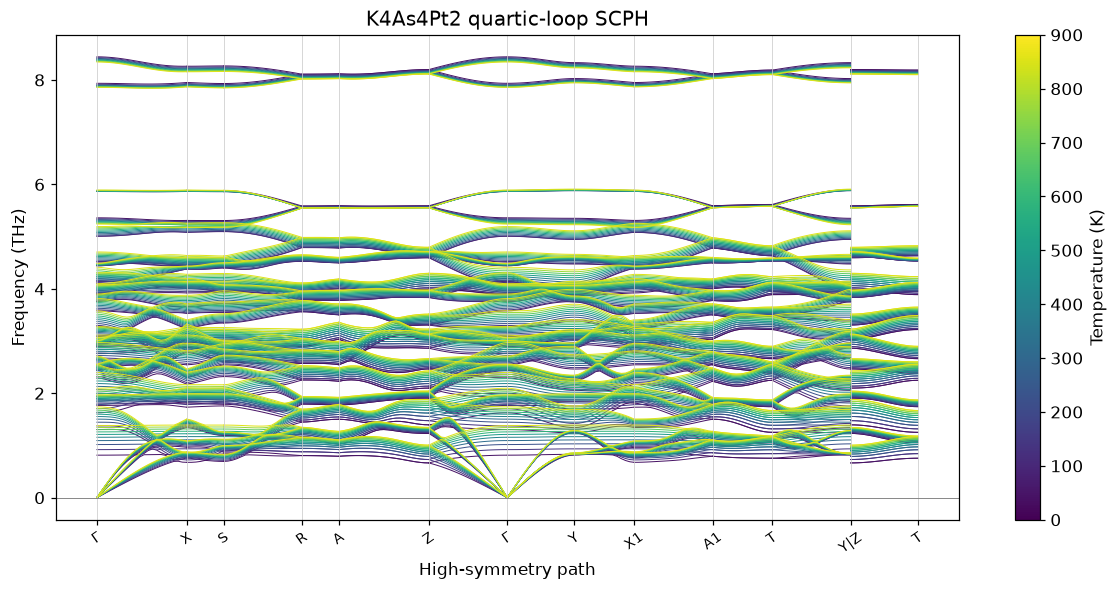

all temperatures converged


In [7]:
fig, axis = plt.subplots(figsize=(11, 5.5))
colors = plt.get_cmap("viridis")(np.linspace(0.05, 0.95, len(results)))
for result, color, bands in zip(results, colors, band_results):
    for segment in bands.segments:
        axis.plot(bands.distances[segment], bands.frequencies_thz[segment], color=color, lw=0.65)
for position in bands.tick_positions:
    axis.axvline(position, color="0.8", lw=0.5)
axis.axhline(0.0, color="0.5", lw=0.6)
axis.set_xticks(bands.tick_positions, bands.tick_labels)
axis.tick_params(axis="x", labelrotation=35, labelsize=9)
axis.set_xlabel("High-symmetry path")
axis.set_ylabel("Frequency (THz)")
axis.set_title("K4As4Pt2 quartic-loop SCPH")
colorbar = fig.colorbar(
    plt.cm.ScalarMappable(
        norm=plt.Normalize(TEMPERATURE_SERIES[0], TEMPERATURE_SERIES[-1]),
        cmap="viridis",
    ),
    ax=axis,
)
colorbar.set_label("Temperature (K)")
fig.tight_layout()
plt.show()

assert all(result.converged for result in results), "some temperature did not converge"
print("all temperatures converged")

## 小结

- 拟合 → 输运 → SCPH 三阶段共用同一份内存模型；`model.write` 的导出与
  phono3py 的消费之间用 `p2s_map` 对齐原子顺序；
- `SCPH.run_many` 的"高温向低温热启动"让整个温度序列以很少的迭代收敛；
- `result.fc2` / `result.frequencies` / `history` 把每一步的自洽过程完整
  暴露，方便做收敛诊断与再分析。